### fbg2107 

# Initial Setup

Before beginning the assignment, we import the CIFAR dataset, and train a simple convolutional neural network (CNN) to classify it.

In [66]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

**Reminder:** set the runtime type to "GPU", or your code will run much more slowly on a CPU.

In [67]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [68]:
print(device)

cuda


In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Load training and test data from the CIFAR10 dataset.

In [69]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False, num_workers=2
)

### for the sake of myself I added showing some of the data

labels: cat | truck | frog | truck


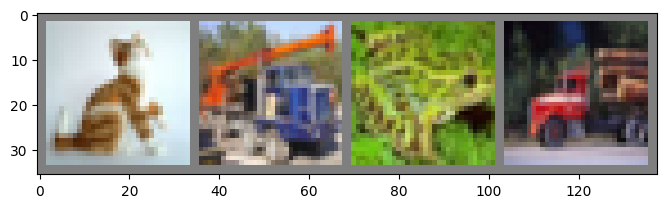

In [70]:
# explore some of the CIFAR-10 data
dataiter = iter(trainloader)
images, labels = next(dataiter)  # get a batch from the iterator


# helper to unnormalize and show a grid of images
def show(img):
    img = img.cpu() * 0.5 + 0.5  # unnormalize (was normalized with mean=0.5, std=0.5)
    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


grid = torchvision.utils.make_grid(images[:8], nrow=8, padding=2)
show(grid)

# print the labels for the displayed images
label_names = [trainset.classes[l] for l in labels[:8]]
print("labels:", " | ".join(label_names))

Define a simple CNN that classifies CIFAR images.

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, bias=False)  # no bias for quantization later
        self.pool = nn.MaxPool2d(2, 2)  # 2x2 max pooling
        self.conv2 = nn.Conv2d(6, 16, 5, bias=False)
        self.fc1 = nn.Linear(16 * 5 * 5, 120, bias=False) 
        self.fc2 = nn.Linear(120, 84, bias=False)
        self.fc3 = nn.Linear(84, 10, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net().to(device)  # move the model to the selected device

Train this CNN on the training dataset (this may take a few moments).

In [72]:
def train(model: nn.Module, dataloader: DataLoader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    for epoch in range(2):  # loop over the dataset multiple times
        running_loss = 0.0
        for i, data in enumerate(dataloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:  # print every 2000 mini-batches
                print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print("Finished Training")


def test(model: nn.Module, dataloader: DataLoader, max_samples=None) -> float:
    correct = 0
    total = 0
    n_inferences = 0

    with torch.no_grad():
        for data in dataloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if max_samples:
                n_inferences += images.shape[0]
                if n_inferences > max_samples:
                    break

    return 100 * correct / total

In [73]:
train(net, trainloader)

[1,  2000] loss: 2.205
[1,  4000] loss: 1.870
[1,  6000] loss: 1.711
[1,  8000] loss: 1.628
[1, 10000] loss: 1.548
[1, 12000] loss: 1.509
[2,  2000] loss: 1.454
[2,  4000] loss: 1.419
[2,  6000] loss: 1.412
[2,  8000] loss: 1.398
[2, 10000] loss: 1.365
[2, 12000] loss: 1.346
Finished Training


Now that the CNN has been trained, let's test it on our test dataset.

In [74]:
score = test(net, testloader)
print("Accuracy of the network on the test images: {}%".format(score))

Accuracy of the network on the test images: 52.03%


In [75]:
from copy import deepcopy


# A convenience function which we use to copy CNNs
def copy_model(model: nn.Module) -> nn.Module:
    result = deepcopy(model)

    # Copy over the extra metadata we've collected which copy.deepcopy doesn't capture
    if hasattr(model, "input_activations"):
        result.input_activations = deepcopy(model.input_activations)

    for result_layer, original_layer in zip(result.children(), model.children()):
        if isinstance(result_layer, nn.Conv2d) or isinstance(result_layer, nn.Linear):
            if hasattr(original_layer.weight, "scale"):
                result_layer.weight.scale = deepcopy(original_layer.weight.scale)
            if hasattr(original_layer, "activations"):
                result_layer.activations = deepcopy(original_layer.activations)
            if hasattr(original_layer, "output_scale"):
                result_layer.output_scale = deepcopy(original_layer.output_scale)

    return result

# Question 1: Visualize Weights

In [76]:
import matplotlib.pyplot as plt
import numpy as np

In [77]:
# ADD YOUR CODE HERE to plot distributions of weights

# You can get a flattened vector of the weights of fc1 like this:
#   fc1_weights = net.fc1.weight.data.cpu().view(-1)
# Try plotting a histogram of fc1_weights (and the weights of all the other layers as well)

fc1_weights = net.fc1.weight.data.cpu().view(-1)
print(fc1_weights, "shape:", fc1_weights.shape)

tensor([ 0.0619,  0.0131,  0.0057,  ...,  0.0178, -0.0325,  0.0176]) shape: torch.Size([48000])


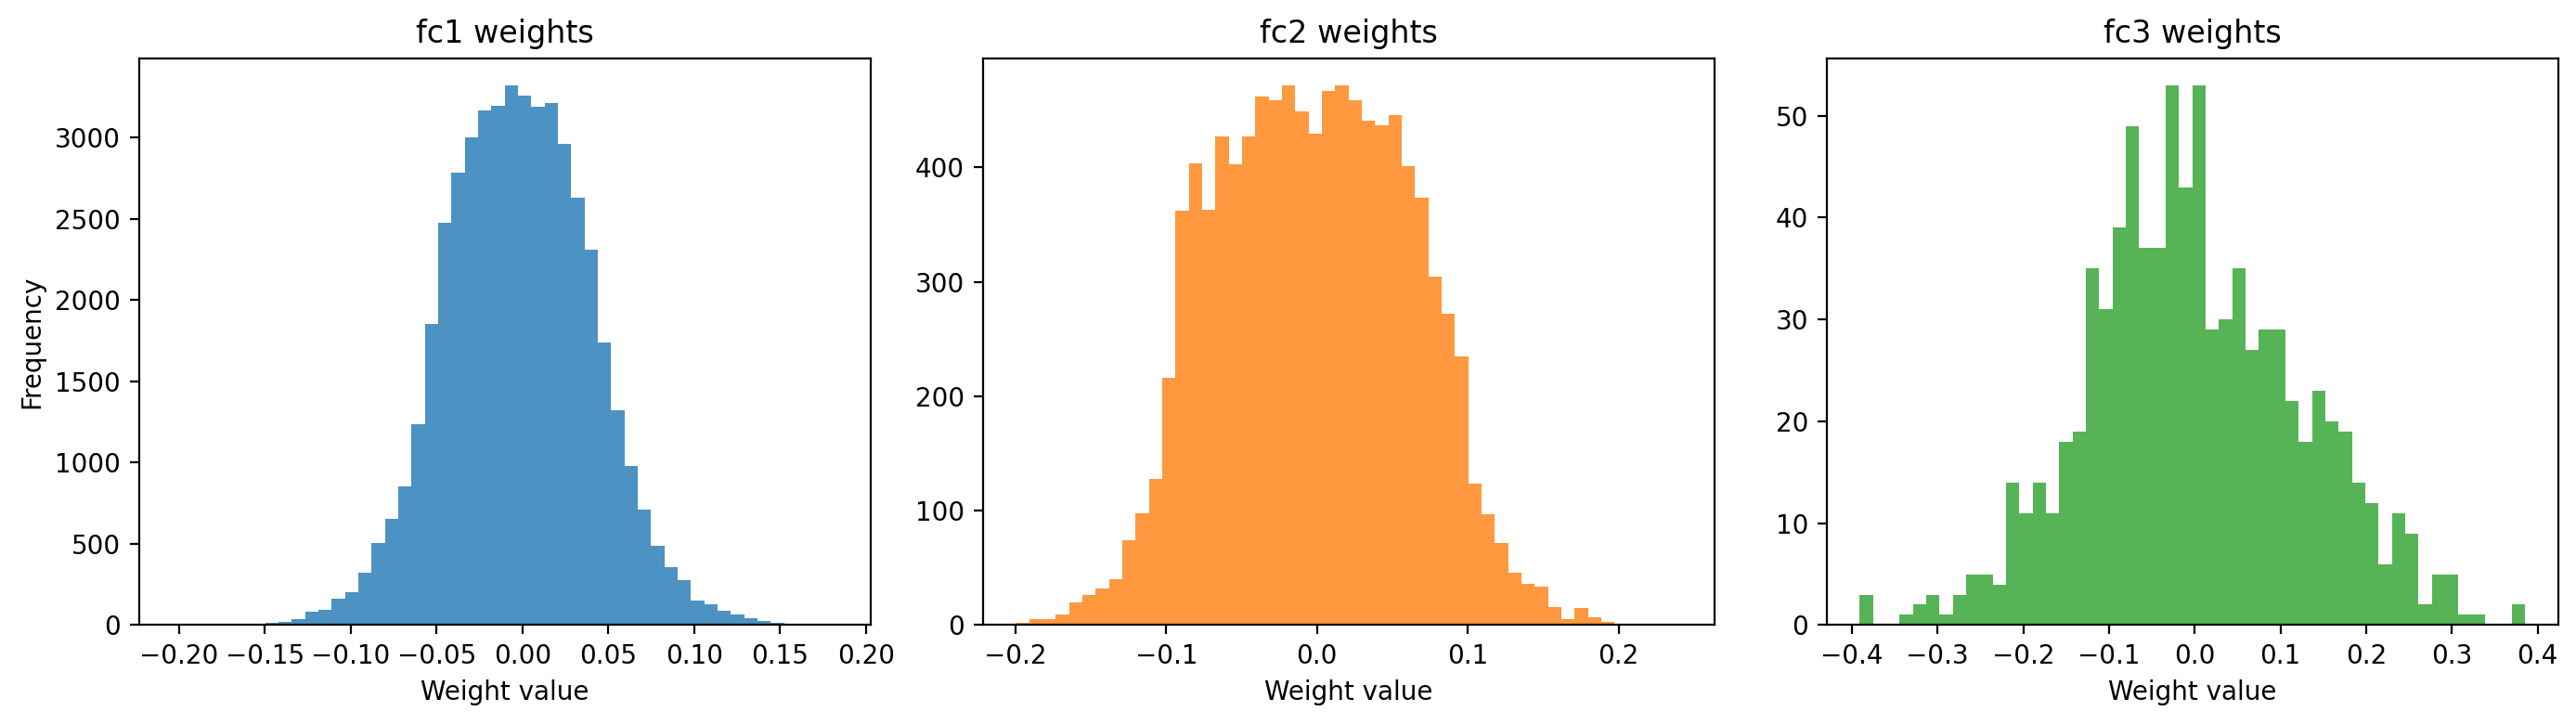

In [78]:
# Combined histogram for fc1, fc2, fc3 weights in a single figure
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=200)

# use existing variables if present, otherwise read from model

fc1 = net.fc1.weight.data.cpu().view(-1)
fc2 = net.fc2.weight.data.cpu().view(-1)
fc3 = net.fc3.weight.data.cpu().view(-1)

axes[0].hist(fc1.numpy(), bins=50, color="C0", alpha=0.8)
axes[0].set(title="fc1 weights", xlabel="Weight value", ylabel="Frequency")

axes[1].hist(fc2.numpy(), bins=50, color="C1", alpha=0.8)
axes[1].set(title="fc2 weights", xlabel="Weight value")

axes[2].hist(fc3.numpy(), bins=50, color="C2", alpha=0.8)
axes[2].set(title="fc3 weights", xlabel="Weight value")

plt.tight_layout()
plt.savefig("./fc1_fc2_fc3_weights_histogram.png", dpi=300)
plt.show()

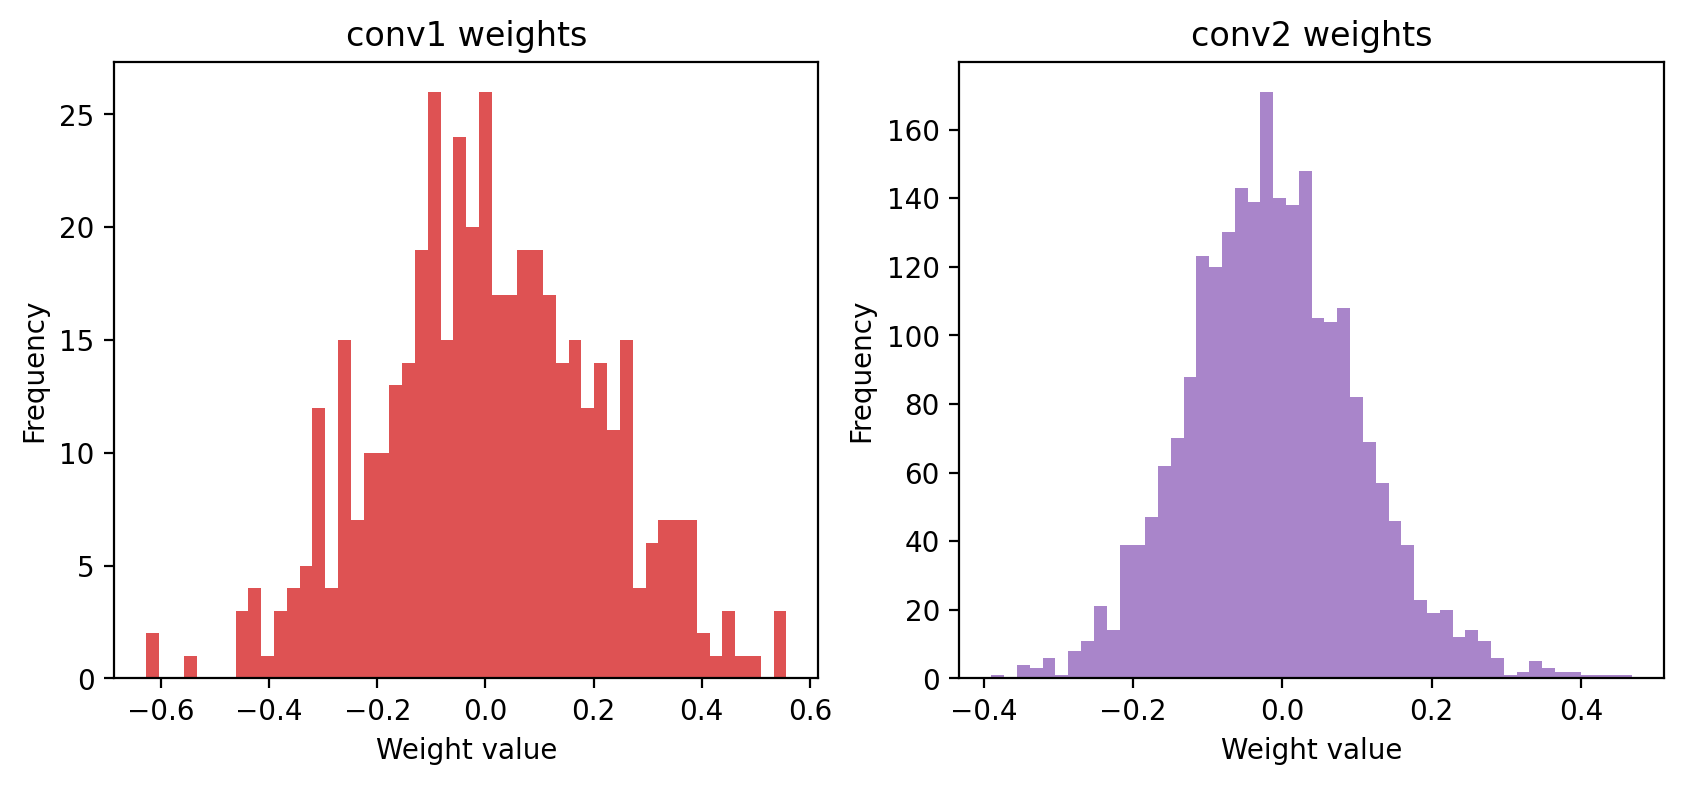

In [79]:
# plot conv1 and conv2
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
conv1 = net.conv1.weight.data.cpu().view(-1)
conv2 = net.conv2.weight.data.cpu().view(-1)
axes[0].hist(conv1.numpy(), bins=50, color="C3", alpha=0.8)
axes[0].set(title="conv1 weights", xlabel="Weight value", ylabel="Frequency")
axes[1].hist(conv2.numpy(), bins=50, color="C4", alpha=0.8)
axes[1].set(title="conv2 weights", xlabel="Weight value", ylabel="Frequency")

plt.savefig("./conv1_conv2_weights_histogram.png", dpi=300)
plt.show()

# Question 2: Quantize Weights

In [80]:
net_q2 = copy_model(net)

In [81]:
from typing import Tuple


def quantized_weights(weights: torch.Tensor) -> Tuple[torch.Tensor, float]:
    """
    Quantize the weights so that all values are integers between -128 and 127.
    You may want to use the total range, 3-sigma range, or some other range when
    deciding just what factors to scale the float32 values by.

    Parameters:
    weights (Tensor): The unquantized weights

    Returns:
    (Tensor, float): A tuple with the following elements:
                        * The weights in quantized form, where every value is an integer between -128 and 127.
                          The "dtype" will still be "float", but the values themselves should all be integers.
                        * The scaling factor that your weights were multiplied by.
                          This value does not need to be an 8-bit integer.
    """

    # ADD YOUR CODE HERE
    # scale = 2.5
    # result = (weights * scale).round()
    # return torch.clamp(result, min=-128, max=127), scale

    # let's make it dependent on the  value of the wieghts, which we see above
    sigma = 3  # we take the hint above
    std = torch.std(weights)

    scale = 127.0 / (sigma * std)
    # actual quantized scale, round to nearest integer, clamp to 8-bit signed range
    quantized = torch.clamp((weights * scale).round(), min=-128, max=127)

    return quantized, scale

In [82]:
def quantize_layer_weights(model: nn.Module):
    for layer in model.children():
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            q_layer_data, scale = quantized_weights(layer.weight.data)
            q_layer_data = q_layer_data.to(device)

            layer.weight.data = q_layer_data
            layer.weight.scale = scale

            if (q_layer_data < -128).any() or (q_layer_data > 127).any():
                raise Exception(
                    "Quantized weights of {} layer include values out of bounds for an 8-bit signed integer".format(
                        layer.__class__.__name__
                    )
                )
            if (q_layer_data != q_layer_data.round()).any():
                raise Exception(
                    "Quantized weights of {} layer include non-integer values".format(
                        layer.__class__.__name__
                    )
                )


quantize_layer_weights(net_q2)

In [83]:
score = test(net_q2, testloader)
print("accuracy of the network after quantizing all weights: {}%".format(score))

accuracy of the network after quantizing all weights: 52.1%


# Question 3: Visualize Activations

In [84]:
def register_activation_profiling_hooks(model: Net):
    model.input_activations = np.empty(0)
    model.conv1.activations = np.empty(0)
    model.conv2.activations = np.empty(0)
    model.fc1.activations = np.empty(0)
    model.fc2.activations = np.empty(0)
    model.fc3.activations = np.empty(0)

    model.profile_activations = True

    def conv1_activations_hook(layer, x, y):
        if model.profile_activations:
            model.input_activations = np.append(
                model.input_activations, x[0].cpu().view(-1)
            )

    model.conv1.register_forward_hook(conv1_activations_hook)

    def conv2_activations_hook(layer, x, y):
        if model.profile_activations:
            model.conv1.activations = np.append(
                model.conv1.activations, x[0].cpu().view(-1)
            )

    model.conv2.register_forward_hook(conv2_activations_hook)

    def fc1_activations_hook(layer, x, y):
        if model.profile_activations:
            model.conv2.activations = np.append(
                model.conv2.activations, x[0].cpu().view(-1)
            )

    model.fc1.register_forward_hook(fc1_activations_hook)

    def fc2_activations_hook(layer, x, y):
        if model.profile_activations:
            model.fc1.activations = np.append(
                model.fc1.activations, x[0].cpu().view(-1)
            )

    model.fc2.register_forward_hook(fc2_activations_hook)

    def fc3_activations_hook(layer, x, y):
        if model.profile_activations:
            model.fc2.activations = np.append(
                model.fc2.activations, x[0].cpu().view(-1)
            )
            model.fc3.activations = np.append(
                model.fc3.activations, y[0].cpu().view(-1)
            )

    model.fc3.register_forward_hook(fc3_activations_hook)

In [85]:
net_q3 = copy_model(net)
register_activation_profiling_hooks(net_q3)

# Run through the training dataset again while profiling the input and output activations this time
# We don't actually have to perform gradient descent for this, so we can use the "test" function
test(net_q3, trainloader, max_samples=400)
net_q3.profile_activations = False

In [86]:
input_activations = net_q3.input_activations
conv1_output_activations = net_q3.conv1.activations
conv2_output_activations = net_q3.conv2.activations
fc1_output_activations = net_q3.fc1.activations
fc2_output_activations = net_q3.fc2.activations
fc3_output_activations = net_q3.fc3.activations

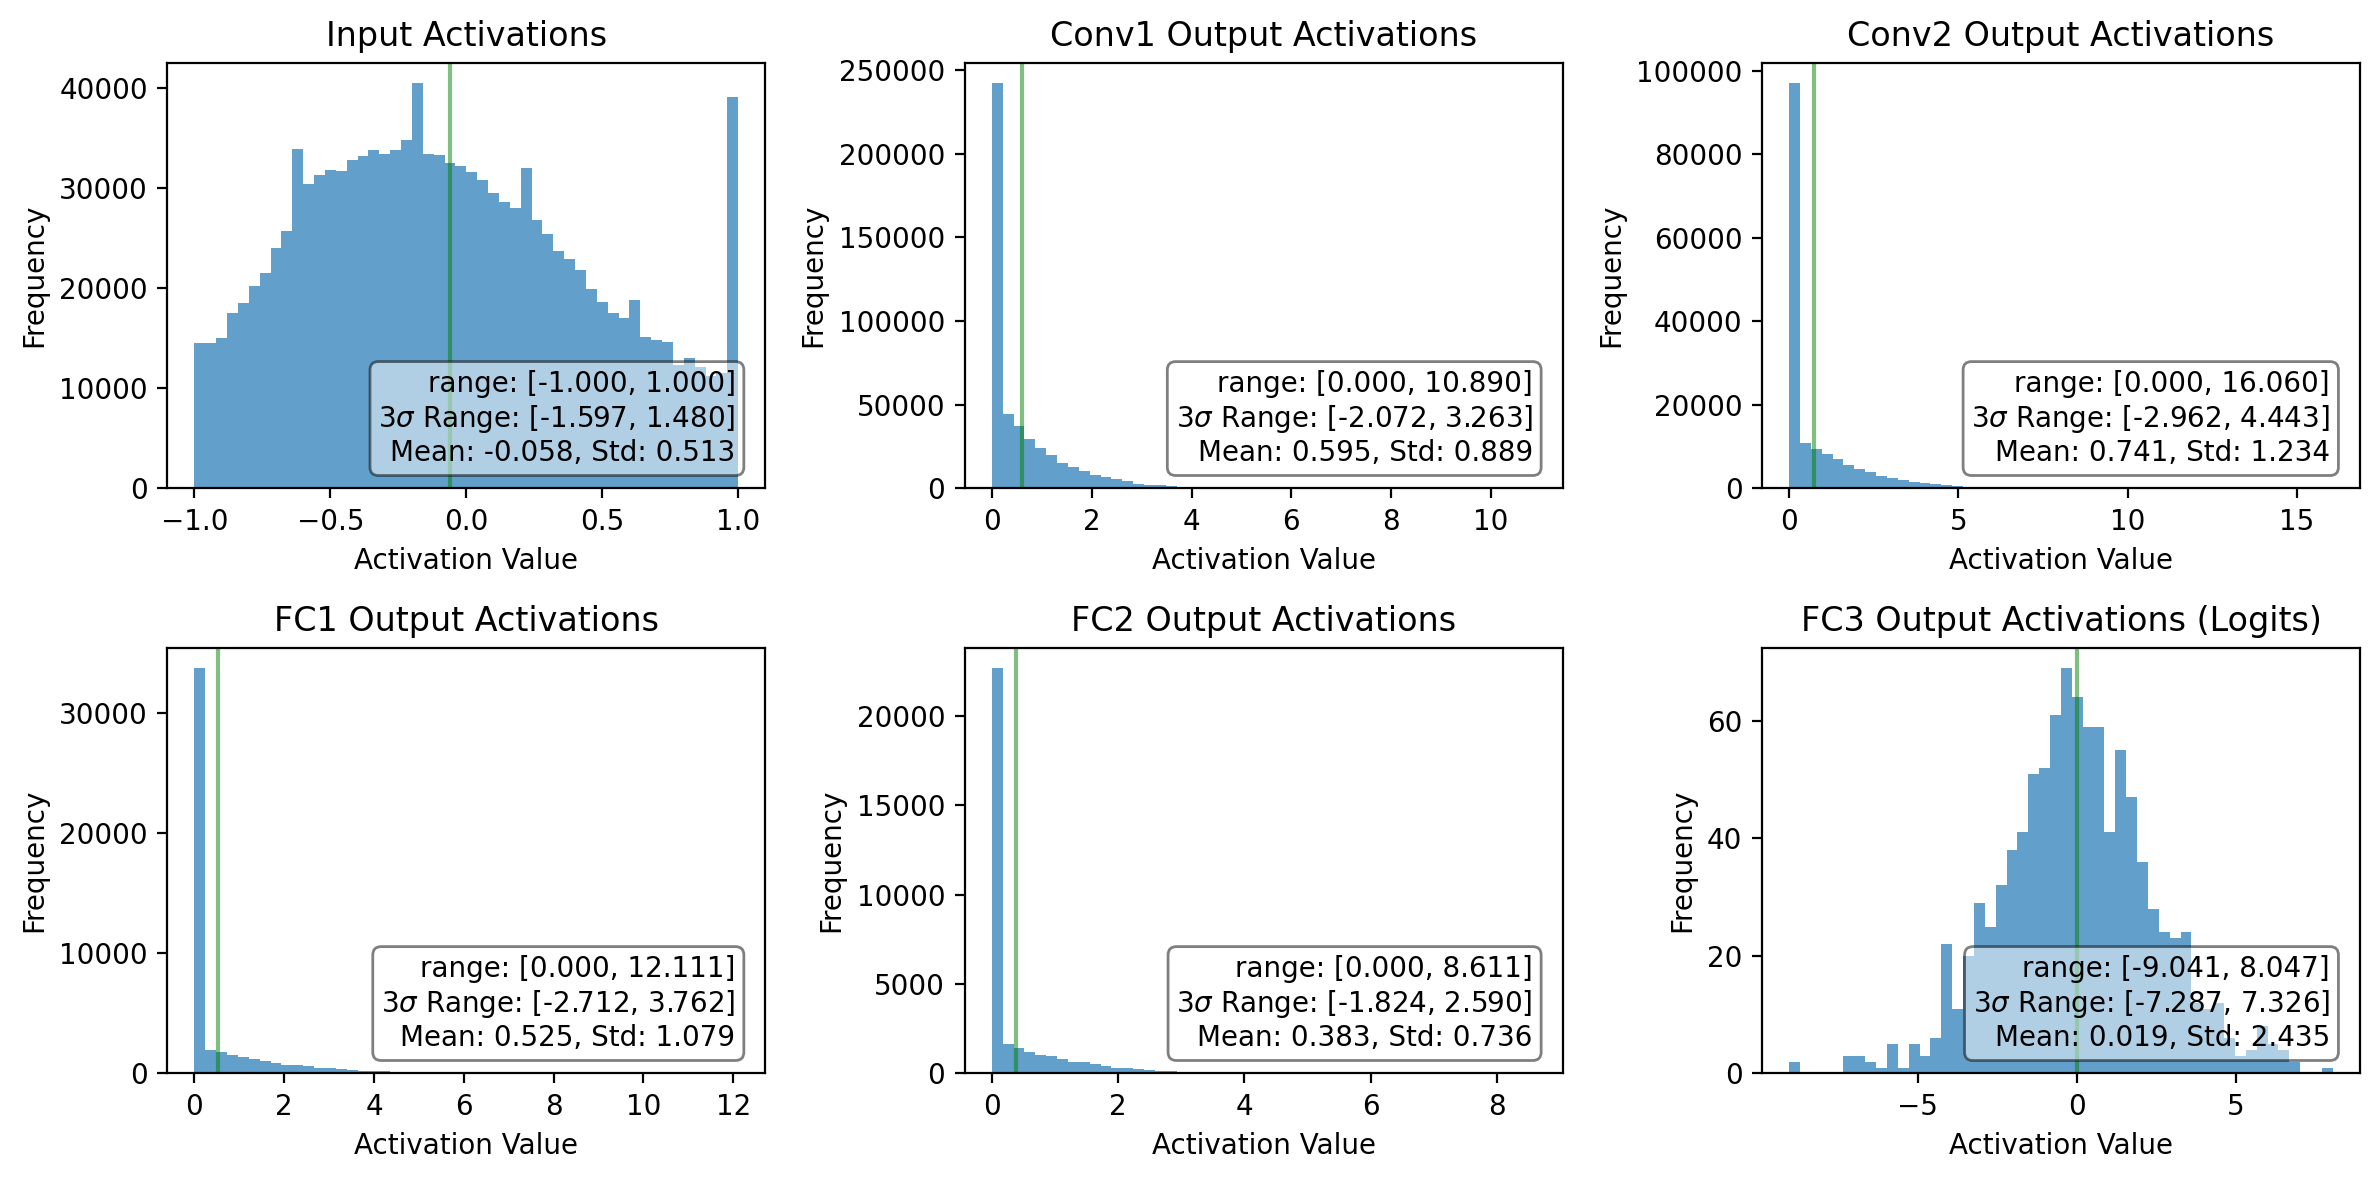

In [99]:
# ADD YOUR CODE HERE to plot distributions of activations

# Plot histograms of the following variables, and calculate their ranges and 3-sigma ranges:
#   input_activations
#   conv1_output_activations
#   conv2_output_activations
#   fc1_output_activations
#   fc2_output_activations
#   fc3_output_activations

# list of activation arrays and their names
activation_arrays = [
    (input_activations, 'Input Activations'),
    (conv1_output_activations, 'Conv1 Output Activations'),
    (conv2_output_activations, 'Conv2 Output Activations'),
    (fc1_output_activations, 'FC1 Output Activations'),
    (fc2_output_activations, 'FC2 Output Activations'),
    (fc3_output_activations, 'FC3 Output Activations (Logits)')
]

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=200)
ax = axes.ravel()  # Flatten the 2x3 grid to 1D array

for idx, (activations, name) in enumerate(activation_arrays):
 
    
    # Convert to numpy array if needed
    if isinstance(activations, torch.Tensor):
        activations_np = activations.cpu().numpy()
    else:
        activations_np = np.array(activations)
    

    ax[idx].hist(activations_np, bins=50, alpha=0.7)
    ax[idx].set_title(name)
    ax[idx].set_xlabel('Activation Value')
    ax[idx].set_ylabel('Frequency')

    mean = np.mean(activations_np)
    std = np.std(activations_np)
    min_val = np.min(activations_np)
    max_val = np.max(activations_np)
    
    # calculate 3-sigma range
    three_sigma_min = mean - 3 * std
    three_sigma_max = mean + 3 * std
    
    # Add text box with statistics
    stats_text = f'range: [{min_val:.3f}, {max_val:.3f}]\n'
    stats_text += r'3$\sigma$ Range: [{:.3f}, {:.3f}]'.format(three_sigma_min, three_sigma_max)
    stats_text += f'\nMean: {mean:.3f}, Std: {std:.3f}'
    
    ax[idx].text(0.95, 0.05, stats_text, transform=ax[idx].transAxes, 
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='w', alpha=0.5))
    
    # add vertical lines for 3-sigma range
    # ax[idx].axvline(three_sigma_min, color='red', linestyle='--', alpha=0.5, label='Mean ± 3σ')
    # ax[idx].axvline(three_sigma_max, color='red', linestyle='--', alpha=0.5)
    ax[idx].axvline(mean, color='green', linestyle='-', alpha=0.5, label='Mean')

plt.tight_layout()
plt.savefig("./activations_histograms.png", dpi=300)
plt.show()

# Question 4: Quantize Activations

In [100]:
from typing import List


class NetQuantized(nn.Module):
    def __init__(self, net_with_weights_quantized: nn.Module):
        super(NetQuantized, self).__init__()

        net_init = copy_model(net_with_weights_quantized)

        self.conv1 = net_init.conv1
        self.pool = net_init.pool
        self.conv2 = net_init.conv2
        self.fc1 = net_init.fc1
        self.fc2 = net_init.fc2
        self.fc3 = net_init.fc3

        for layer in self.conv1, self.conv2, self.fc1, self.fc2, self.fc3:

            def pre_hook(l, x):
                x = x[0]
                if (x < -128).any() or (x > 127).any():
                    raise Exception(
                        "Input to {} layer is out of bounds for an 8-bit signed integer".format(
                            l.__class__.__name__
                        )
                    )
                if (x != x.round()).any():
                    raise Exception(
                        "Input to {} layer has non-integer values".format(
                            l.__class__.__name__
                        )
                    )

            layer.register_forward_pre_hook(pre_hook)

        # Calculate the scaling factor for the initial input to the CNN
        self.input_activations = net_with_weights_quantized.input_activations
        self.input_scale = NetQuantized.quantize_initial_input(self.input_activations)

        # Calculate the output scaling factors for all the layers of the CNN
        preceding_layer_scales = []
        for layer in self.conv1, self.conv2, self.fc1, self.fc2, self.fc3:
            layer.output_scale = NetQuantized.quantize_activations(
                layer.activations,
                layer.weight.scale,
                self.input_scale,
                preceding_layer_scales,
            )
            preceding_layer_scales.append((layer.weight.scale, layer.output_scale))

    @staticmethod
    def quantize_initial_input(pixels: np.ndarray) -> float:
        """
        Calculate a scaling factor for the images that are input to the first layer of the CNN.

        Parameters:
        pixels (ndarray): The values of all the pixels which were part of the input image during training

        Returns:
        float: A scaling factor that the input should be multiplied by before being fed into the first layer.
               This value does not need to be an 8-bit integer.
        """

        # ADD YOUR CODE HERE
        
        # return 1.0
        
        # input is already normalized to [-1, 1] and  want to map this range -> [-128, 127]
        max_abs = np.max(np.abs(pixels))
        
        if max_abs == 0:
            return 1.0
        
        # scale so that max_abs maps to 127 (not 128) to avoid potential overflow
        scale = 127.0 / max_abs
        
        # std = np.std(np.abs(pixels))
        # if std > 0:
        #     scale = 127.0 / (3.0 * std)
        
        return scale
    

    @staticmethod
    def quantize_activations(
        activations: np.ndarray,
        n_w: float,
        n_initial_input: float,
        ns: List[Tuple[float, float]],
    ) -> float:
        """
        Calculate a scaling factor to multiply the output of a layer by.

        Parameters:
        activations (ndarray): The values of all the pixels which have been output by this layer during training
        n_w (float): The scale by which the weights of this layer were multiplied as part of the "quantize_weights" function you wrote earlier
        n_initial_input (float): The scale by which the initial input to the neural network was multiplied
        ns ([(float, float)]): A list of tuples, where each tuple represents the "weight scale" and "output scale" (in that order) for every preceding layer

        Returns:
        float: A scaling factor that the layer output should be multiplied by before being fed into the first layer.
               This value does not need to be an 8-bit integer.
        """

        # ADD YOUR CODE HERE
        # return 1.0
        
        activations_np = np.array(activations)
    
        cumulative_scale = n_initial_input
        
        for prev_weight_scale, prev_output_scale in ns:
            cumulative_scale *= prev_weight_scale * prev_output_scale
        
        
        max_abs = np.max(np.abs(activations_np)) # find the maximum absolute activation value
        
        if max_abs == 0:
            return 1.0  # all activations are zero
        
        # quantized_output ~ floating_activation x (cumulative_scale x n_w x n_output)
        # we want |quantized_output| =< 127
        # therefore: n_output = 127 / (max_abs x cumulative_scale x n_w)
        
        scale_product = cumulative_scale * n_w
        
        if scale_product == 0:
            return 1.0 
        
        n_output = 127.0 / (max_abs * scale_product)
        
        return n_output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # You can access the output activation scales like this:
        #   fc1_output_scale = self.fc1.output_scale

        # To make sure that the outputs of each layer are integers between -128 and 127, you may need to use the following functions:
        #   * torch.Tensor.round
        #   * torch.clamp

        # ADD YOUR CODE HERE
        # return torch.Tensor(
        #     [
        #         [1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        #         [1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        #         [1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        #         [1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        #     ]
        # ).to(device)P

        # return x
        
        # scale and quantize the input
        x = (x * self.input_scale).round() # as instructed
        x = torch.clamp(x, min=-128, max=127)
        
        # process through conv1
        x = self.conv1(x)           # integer weights × integer input
        x = F.relu(x)               # ReLU (sets negatives to 0)
        x = (x * self.conv1.output_scale).round()  # scale output
        x = torch.clamp(x, min=-128, max=127)      # clamp to 8-bit range
        x = self.pool(x)            # max pooling (works on integers)
        
        # process through conv2
        x = self.conv2(x)
        x = F.relu(x)
        x = (x * self.conv2.output_scale).round()
        x = torch.clamp(x, min=-128, max=127)
        x = self.pool(x)
        
        # flatten for fully connected layers
        x = x.view(-1, 16 * 5 * 5)
        
        # process through fc1
        x = self.fc1(x)
        x = F.relu(x)
        x = (x * self.fc1.output_scale).round()
        x = torch.clamp(x, min=-128, max=127)
        
        # process through fc2
        x = self.fc2(x)
        x = F.relu(x)
        x = (x * self.fc2.output_scale).round()
        x = torch.clamp(x, min=-128, max=127)
        
        # process through fc3 (no ReLU for final layer)
        x = self.fc3(x)
        x = (x * self.fc3.output_scale).round()
        x = torch.clamp(x, min=-128, max=127)
        
        return x

In [101]:
# Merge the information from net_q2 and net_q3 together
net_init = copy_model(net_q2)
net_init.input_activations = deepcopy(net_q3.input_activations)
for layer_init, layer_q3 in zip(net_init.children(), net_q3.children()):
    if isinstance(layer_init, nn.Conv2d) or isinstance(layer_init, nn.Linear):
        layer_init.activations = deepcopy(layer_q3.activations)

net_quantized = NetQuantized(net_init)

In [102]:
score = test(net_quantized, testloader)
print(
    "Accuracy of the network after quantizing both weights and activations: {}%".format(
        score
    )
)

Accuracy of the network after quantizing both weights and activations: 52.21%


# Question 5: Quantize Biases

In [117]:
class NetWithBias(nn.Module):
    def __init__(self):
        super(NetWithBias, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, 5, bias=False)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5, bias=False)
        self.fc1 = nn.Linear(16 * 5 * 5, 120, bias=False)
        self.fc2 = nn.Linear(120, 84, bias=False)
        self.fc3 = nn.Linear(84, 10, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        # handles the bias
        # x = (x * self.fc3.output_scale).round()
        # x = torch.clamp(x, min=-128, max=127)
        return x


net_with_bias = NetWithBias().to(device)

In [118]:
train(net_with_bias, trainloader)

[1,  2000] loss: 2.145
[1,  4000] loss: 1.854
[1,  6000] loss: 1.646
[1,  8000] loss: 1.594
[1, 10000] loss: 1.541
[1, 12000] loss: 1.489
[2,  2000] loss: 1.438
[2,  4000] loss: 1.405
[2,  6000] loss: 1.399
[2,  8000] loss: 1.383
[2, 10000] loss: 1.355
[2, 12000] loss: 1.304
Finished Training


In [119]:
score = test(net_with_bias, testloader)
print("Accuracy of the network (with a bias) on the test images: {}%".format(score))

Accuracy of the network (with a bias) on the test images: 50.06%


In [120]:
register_activation_profiling_hooks(net_with_bias)
test(net_with_bias, trainloader, max_samples=400)
net_with_bias.profile_activations = False

In [121]:
net_with_bias_with_quantized_weights = copy_model(net_with_bias)
quantize_layer_weights(net_with_bias_with_quantized_weights)

score = test(net_with_bias_with_quantized_weights, testloader)
print(
    "Accuracy of the network on the test images after all the weights are quantized but the bias isn't: {}%".format(
        score
    )
)

Accuracy of the network on the test images after all the weights are quantized but the bias isn't: 46.9%


In [122]:
class NetQuantizedWithBias(NetQuantized):
    def __init__(self, net_with_weights_quantized: nn.Module):
        super(NetQuantizedWithBias, self).__init__(net_with_weights_quantized)

        preceding_scales = [
            (layer.weight.scale, layer.output_scale)
            for layer in self.children()
            if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear)
        ][:-1]

        self.fc3.bias.data = NetQuantizedWithBias.quantized_bias(
            self.fc3.bias.data,
            self.fc3.weight.scale,
            self.input_scale,
            preceding_scales,
        )

        if (self.fc3.bias.data < -2147483648).any() or (
            self.fc3.bias.data > 2147483647
        ).any():
            raise Exception(
                "Bias has values which are out of bounds for an 32-bit signed integer"
            )
        if (self.fc3.bias.data != self.fc3.bias.data.round()).any():
            raise Exception("Bias has non-integer values")

    @staticmethod
    def quantized_bias(
        bias: torch.Tensor,
        n_w: float,
        n_initial_input: float,
        ns: List[Tuple[float, float]],
    ) -> torch.Tensor:
        """
        Quantize the bias so that all values are integers between -2147483648 and 2147483647.

        Parameters:
        bias (Tensor): The floating point values of the bias
        n_w (float): The scale by which the weights of this layer were multiplied
        n_initial_input (float): The scale by which the initial input to the neural network was multiplied
        ns ([(float, float)]): A list of tuples, where each tuple represents the "weight scale" and "output scale" (in that order) for every preceding layer

        Returns:
        Tensor: The bias in quantized form, where every value is an integer between -2147483648 and 2147483647.
                The "dtype" will still be "float", but the values themselves should all be integers.
        """

        # ADD YOUR CODE HERE
        # return torch.clamp((bias * 2.5).round(), min=-2147483648, max=2147483647)
        
        cumulative_scale = n_initial_input
        
        for prev_weight_scale, prev_output_scale in ns:
            cumulative_scale *= prev_weight_scale * prev_output_scale
        
        total_scale = cumulative_scale * n_w
        
        # quantize the bias
        bias_quantized = (bias * total_scale).round()
        
        # clamp to 32-bit signed integer range
        bias_quantized = torch.clamp(bias_quantized, min=-2147483648, max=2147483647)
        
        return bias_quantized

In [123]:
net_quantized_with_bias = NetQuantizedWithBias(net_with_bias_with_quantized_weights)

In [124]:
score = test(net_quantized_with_bias, testloader)
print(
    "Accuracy of the network on the test images after all the weights and the bias are quantized: {}%".format(
        score
    )
)

Accuracy of the network on the test images after all the weights and the bias are quantized: 50.48%
